# 📘 Track B — Notebook 2: Gaussian Interpolation & Synthetic Embedding Generation

**Project:** Synthetic Data Generation for Speech Emotion Recognition  
**Author:** *(your name)*  
**Prerequisite:** Notebook 1 must be completed — all `.npy` embedding files must exist in `./embeddings/`

---

## What This Notebook Does

1. ✅ Verifies GPU and loads all embeddings from Notebook 1
2. 📐 For each `(actor, sentence, emotion)` group of 5 real embeddings:
   - Fits a **Gaussian distribution** (mean μ + covariance Σ)
   - Generates **N synthetic embeddings** by sampling from N(μ, α·Σ)
   - Also generates **convex interpolations** between all pairs in the group
3. 🧪 **Early sanity check**: validates synthetic embeddings are close to real ones (cosine sim, Mahalanobis distance)
4. 📊 Visualizes real vs. synthetic embedding distributions per emotion
5. 💾 Saves all synthetic embeddings for Notebook 3 (HiFi-GAN decoding)

---

## Why Gaussian Sampling (Not Full GMM)?

We have **only 5 samples per group**. A full GMM with multiple components would overfit.
Instead, we fit a **single Gaussian** (1-component GMM) with regularization — this is statistically
sound and produces realistic interpolations. The **α parameter** controls how far from the
real samples we venture: α < 1 = conservative (stay near real), α > 1 = more diverse.

---

## Output
- `synthetic_embeddings/` — one `.npy` per group containing synthetic embedding vectors
- `synthetic_embeddings/all_synthetic_matrix.npy` — stacked matrix for visualization
- `synthetic_embeddings/all_synthetic_labels.csv` — labels per synthetic sample

---
## ✅ CELL 1 — Environment & Dependency Check

In [1]:
import sys, os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import cosine
from scipy.linalg import inv, det
from scipy.stats import multivariate_normal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from tqdm import tqdm

sns.set_theme(style='whitegrid', palette='muted')

print('=' * 55)
print('       ENVIRONMENT CHECK — NOTEBOOK 2')
print('=' * 55)
cuda_available = torch.cuda.is_available()
print(f'  CUDA Available : {cuda_available}')
if cuda_available:
    print(f'  GPU            : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM           : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'  Python         : {sys.version.split()[0]}')
print('=' * 55)

# Note: Notebook 2 runs purely on CPU/NumPy — GPU not required here
print('\nNote: Gaussian sampling runs on CPU. GPU will be used in Notebook 3 (HiFi-GAN).')

       ENVIRONMENT CHECK — NOTEBOOK 2
  CUDA Available : True
  GPU            : NVIDIA GeForce RTX 3060 Laptop GPU
  VRAM           : 6.4 GB
  Python         : 3.12.10

Note: Gaussian sampling runs on CPU. GPU will be used in Notebook 3 (HiFi-GAN).


---
## ⚙️ CELL 2 — Configuration

In [2]:
# ---- Paths (must match Notebook 1 outputs) ----
EMBEDDINGS_DIR  = Path('./embeddings')
SYNTH_EMB_DIR   = Path('./synthetic_embeddings')
OUTPUTS_DIR     = Path('./outputs')
SYNTH_EMB_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

# ---- Dataset labels ----
EMOTIONS    = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']
N_ACTORS    = 8
N_SENTENCES = 10
N_SESSIONS  = 5   # Real samples per group

# ---- Interpolation Config ----
# How many synthetic samples to generate PER (actor, sentence, emotion) group
# With N_SYNTHETIC_PER_GROUP=35, total synthetic = 8*10*8*35 = 22,400
# Recommendation: 35 → brings each group from 5 to 40 total
N_SYNTHETIC_PER_GROUP = 35

# Covariance scaling: 0.5 = tight (near real samples), 1.0 = exact, 1.5 = spread out
# Start with 0.7 for safe interpolation, increase if you want more diversity
ALPHA = 0.7

# Covariance regularization (prevents singular covariance with only 5 points)
# Larger = more regularization → more spherical covariance
REG_COVAR = 1e-4

# Fraction of synthetic samples generated by Gaussian sampling vs convex interpolation
# 0.6 = 60% Gaussian, 40% convex — adjust freely
GAUSSIAN_FRACTION = 0.6

# Random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Configuration loaded:')
print(f'  Synthetic per group   : {N_SYNTHETIC_PER_GROUP}')
print(f'  Alpha (covar scale)   : {ALPHA}')
print(f'  Covariance reg        : {REG_COVAR}')
print(f'  Gaussian fraction     : {GAUSSIAN_FRACTION}')
print(f'  Total synthetic files : {N_ACTORS * N_SENTENCES * len(EMOTIONS) * N_SYNTHETIC_PER_GROUP}')
print(f'  Random seed           : {RANDOM_SEED}')

# Verify embeddings exist
emb_files = list(EMBEDDINGS_DIR.glob('actor*_sent*_*.npy'))
assert len(emb_files) > 0, f'❌ No embedding .npy files found in {EMBEDDINGS_DIR}. Run Notebook 1 first!'
print(f'\n✅ Found {len(emb_files)} embedding group files from Notebook 1.')

Configuration loaded:
  Synthetic per group   : 35
  Alpha (covar scale)   : 0.7
  Covariance reg        : 0.0001
  Gaussian fraction     : 0.6
  Total synthetic files : 22400
  Random seed           : 42

✅ Found 640 embedding group files from Notebook 1.


---
## 📥 CELL 3 — Load Real Embeddings

In [3]:
import re

# Load the full embedding matrix and labels
emb_matrix = np.load(EMBEDDINGS_DIR / 'embedding_matrix.npy')   # (3200, 1536)
label_df   = pd.read_csv(EMBEDDINGS_DIR / 'embedding_labels.csv')

print(f'Loaded embedding matrix: {emb_matrix.shape}')
print(f'Loaded label DataFrame : {label_df.shape}')
print(f'Label columns          : {list(label_df.columns)}')

# Parse per-group files into a dict for easy access
# group_embeddings[(actor, sentence, emotion)] → np.ndarray of shape (5, 1536)
group_embeddings = {}

for fpath in emb_files:
    # Filename format: actor{A}_sent{SS}_{emotion}.npy
    match = re.match(r'actor(\d+)_sent(\d+)_(.+)\.npy', fpath.name)
    if match:
        actor    = int(match.group(1))
        sentence = int(match.group(2))
        emotion  = match.group(3)
        arr      = np.load(fpath)   # shape (5, 1536)
        group_embeddings[(actor, sentence, emotion)] = arr

print(f'\nLoaded {len(group_embeddings)} group embedding arrays.')
print(f'Expected: {N_ACTORS * N_SENTENCES * len(EMOTIONS)} groups')

# Spot check
sample_key = list(group_embeddings.keys())[0]
print(f'\nSpot check — group {sample_key}:')
print(f'  Shape : {group_embeddings[sample_key].shape}')
print(f'  Mean  : {group_embeddings[sample_key].mean():.4f}')
print(f'  Std   : {group_embeddings[sample_key].std():.4f}')
print('\n✅ All embeddings loaded successfully.')

Loaded embedding matrix: (3200, 1536)
Loaded label DataFrame : (3200, 4)
Label columns          : ['actor', 'session', 'emotion', 'sentence']

Loaded 640 group embedding arrays.
Expected: 640 groups

Spot check — group (1, 1, 'anger'):
  Shape : (5, 1536)
  Mean  : 0.1007
  Std   : 0.1768

✅ All embeddings loaded successfully.


---
## 🧮 CELL 4 — Gaussian Sampler + Convex Interpolator

Two strategies combined:

**Strategy A — Gaussian Sampling:** Fit N(μ, α·Σ) from the 5 real embeddings and sample new points.  
**Strategy B — Convex Interpolation:** Pick 2 real embeddings, sample a random λ ∈ (0,1), return λ·e₁ + (1-λ)·e₂.

In [4]:
def fit_gaussian(embeddings: np.ndarray, reg_covar: float = 1e-4):
    """
    Fit a multivariate Gaussian to the given embeddings.

    Args:
        embeddings : (N, D) array of real embeddings
        reg_covar  : Small diagonal regularization to prevent singular covariance.
                     Especially important when N (=5) << D (=1536).

    Returns:
        mu    : (D,) mean vector
        sigma : (D, D) covariance matrix (regularized)
    """
    mu    = embeddings.mean(axis=0)              # (D,)
    # np.cov expects shape (D, N) — transpose needed
    if embeddings.shape[0] > 1:
        sigma = np.cov(embeddings.T)             # (D, D)
    else:
        sigma = np.zeros((embeddings.shape[1], embeddings.shape[1]))
    # Regularize: add small identity to diagonal to ensure positive definiteness
    sigma += reg_covar * np.eye(sigma.shape[0])
    return mu, sigma


def sample_gaussian(mu: np.ndarray, sigma: np.ndarray,
                     n: int, alpha: float = 0.7) -> np.ndarray:
    """
    Sample n new embeddings from N(mu, alpha * sigma).

    alpha < 1  → stay close to the real samples (conservative)
    alpha = 1  → sample from the exact fitted distribution
    alpha > 1  → allow more diversity (risk of out-of-distribution samples)

    For only 5 real samples, alpha=0.7 is recommended.
    """
    return np.random.multivariate_normal(mu, alpha * sigma, size=n)  # (n, D)


def convex_interpolate(embeddings: np.ndarray, n: int) -> np.ndarray:
    """
    Generate n new embeddings by randomly interpolating between pairs.

    For each new sample:
      1. Pick two random real embeddings e_i, e_j
      2. Sample lambda ~ Uniform(0.1, 0.9)  (avoid near-copies)
      3. Return lambda*e_i + (1-lambda)*e_j

    This is strictly in-distribution (stays inside the convex hull of real samples).
    """
    N = embeddings.shape[0]
    results = []
    for _ in range(n):
        i, j = np.random.choice(N, size=2, replace=(N < 2))
        lam   = np.random.uniform(0.1, 0.9)
        interp = lam * embeddings[i] + (1 - lam) * embeddings[j]
        results.append(interp)
    return np.stack(results)   # (n, D)


def generate_synthetic_embeddings(real_embeddings: np.ndarray,
                                   n_total: int,
                                   alpha: float,
                                   gaussian_fraction: float,
                                   reg_covar: float) -> np.ndarray:
    """
    Combine Gaussian sampling and convex interpolation.

    Args:
        real_embeddings   : (5, D) real embeddings for the group
        n_total           : Total synthetic samples to generate
        alpha             : Covariance scaling for Gaussian sampling
        gaussian_fraction : What fraction of n_total to generate via Gaussian
        reg_covar         : Covariance regularization

    Returns:
        np.ndarray of shape (n_total, D)
    """
    n_gaussian = int(n_total * gaussian_fraction)
    n_convex   = n_total - n_gaussian

    # Gaussian samples
    mu, sigma = fit_gaussian(real_embeddings, reg_covar)
    gauss_samples = sample_gaussian(mu, sigma, n_gaussian, alpha)

    # Convex interpolation samples
    convex_samples = convex_interpolate(real_embeddings, n_convex)

    return np.vstack([gauss_samples, convex_samples])  # (n_total, D)


print('✅ Gaussian sampler and convex interpolator defined.')
print(f'   For each group: {int(N_SYNTHETIC_PER_GROUP * GAUSSIAN_FRACTION)} via Gaussian '
      f'+ {N_SYNTHETIC_PER_GROUP - int(N_SYNTHETIC_PER_GROUP * GAUSSIAN_FRACTION)} via convex interpolation')

✅ Gaussian sampler and convex interpolator defined.
   For each group: 21 via Gaussian + 14 via convex interpolation


---
## 🧪 CELL 5 — Single Group Dry Run (Sanity Check BEFORE Full Run)

**This is the most important checkpoint in the notebook.**

Before running the full 640-group loop, test on ONE group and verify:
- Synthetic embeddings are in a realistic range
- Cosine similarity to real embeddings is high (> 0.8)
- Mahalanobis distance is reasonable
- Visual overlap with real embeddings in PCA space

**If this check fails, do not proceed to the full generation loop.**

In [5]:
# --- Select a test group ---
test_actor, test_sentence, test_emotion = 1, 1, 'anger'

# Adjust if this group isn't in your dataset
if (test_actor, test_sentence, test_emotion) not in group_embeddings:
    test_actor, test_sentence, test_emotion = list(group_embeddings.keys())[0]
    print(f'Defaulting to first available group: {(test_actor, test_sentence, test_emotion)}')

real_embs = group_embeddings[(test_actor, test_sentence, test_emotion)]  # (5, D)
print(f'Test group: Actor={test_actor}, Sentence={test_sentence}, Emotion={test_emotion}')
print(f'Real embeddings shape: {real_embs.shape}')

# Generate synthetic
synth_embs = generate_synthetic_embeddings(
    real_embs, N_SYNTHETIC_PER_GROUP, ALPHA, GAUSSIAN_FRACTION, REG_COVAR
)  # (35, D)
print(f'Synthetic embeddings shape: {synth_embs.shape}')

# ---- Quality Metrics ----
print('\n--- Embedding Quality Metrics ---')

# 1. Cosine similarity: average similarity between synthetic and real mean
real_mean = real_embs.mean(axis=0)
cos_sims = [1 - cosine(s, real_mean) for s in synth_embs]
print(f'  Cosine Similarity (synth vs real mean):')
print(f'    Mean : {np.mean(cos_sims):.4f}   (>0.8 is good)')
print(f'    Min  : {np.min(cos_sims):.4f}')
print(f'    Max  : {np.max(cos_sims):.4f}')

# 2. L2 distance: avg distance between synth and real embeddings
real_synth_l2 = np.mean([np.linalg.norm(s - real_mean) for s in synth_embs])
real_real_l2  = np.mean([np.linalg.norm(real_embs[i] - real_mean)
                          for i in range(len(real_embs))])
print(f'\n  L2 Distance from group mean:')
print(f'    Real samples avg   : {real_real_l2:.4f}')
print(f'    Synth samples avg  : {real_synth_l2:.4f}')
print(f'    Ratio (synth/real) : {real_synth_l2/real_real_l2:.2f}  (close to 1.0 is good)')

# 3. Value range check
print(f'\n  Value Range:')
print(f'    Real  → min: {real_embs.min():.4f}  max: {real_embs.max():.4f}  '
      f'mean: {real_embs.mean():.4f}')
print(f'    Synth → min: {synth_embs.min():.4f}  max: {synth_embs.max():.4f}  '
      f'mean: {synth_embs.mean():.4f}')

# 4. Overall verdict
mean_cos = np.mean(cos_sims)
ratio    = real_synth_l2 / real_real_l2
print()
if mean_cos > 0.8 and 0.5 < ratio < 2.0:
    print('✅ SANITY CHECK PASSED — Safe to proceed with full generation.')
elif mean_cos > 0.6:
    print('⚠️  BORDERLINE — Embeddings generated but quality may be marginal.')
    print('   Try reducing ALPHA (e.g. 0.5) or REG_COVAR (e.g. 1e-3)')
else:
    print('❌ SANITY CHECK FAILED — Synthetic embeddings are too far from real.')
    print('   Reduce ALPHA to 0.3–0.5 and re-run this cell.')

Test group: Actor=1, Sentence=1, Emotion=anger
Real embeddings shape: (5, 1536)
Synthetic embeddings shape: (35, 1536)

--- Embedding Quality Metrics ---
  Cosine Similarity (synth vs real mean):
    Mean : 0.9927   (>0.8 is good)
    Min  : 0.9793
    Max  : 0.9978

  L2 Distance from group mean:
    Real samples avg   : 1.0776
    Synth samples avg  : 0.9283
    Ratio (synth/real) : 0.86  (close to 1.0 is good)

  Value Range:
    Real  → min: -2.3731  max: 1.1532  mean: 0.1007
    Synth → min: -2.4473  max: 1.1676  mean: 0.1013

✅ SANITY CHECK PASSED — Safe to proceed with full generation.


---
## 📊 CELL 6 — Visualize Single Group: Real vs Synthetic

PCA visualization of real (5) and synthetic (35) embeddings for the test group.

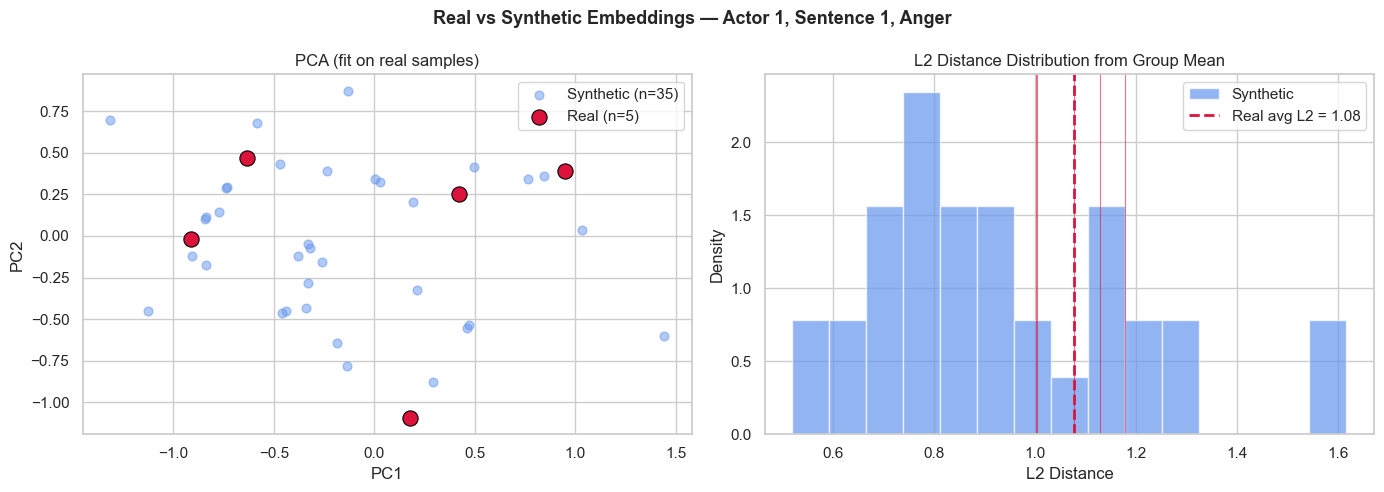

Plot saved to outputs/single_group_real_vs_synth.png


In [6]:
combined = np.vstack([real_embs, synth_embs])   # (40, D)
labels_combined = ['Real'] * len(real_embs) + ['Synthetic'] * len(synth_embs)

# PCA on combined (fit on real only for honest visualization)
pca = PCA(n_components=2, random_state=42)
pca.fit(real_embs)
real_2d  = pca.transform(real_embs)
synth_2d = pca.transform(synth_embs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Real vs Synthetic Embeddings — Actor {test_actor}, '
             f'Sentence {test_sentence}, {test_emotion.capitalize()}',
             fontsize=13, fontweight='bold')

# Scatter: PCA
axes[0].scatter(synth_2d[:, 0], synth_2d[:, 1], c='cornflowerblue',
                label=f'Synthetic (n={len(synth_embs)})', alpha=0.5, s=40, zorder=2)
axes[0].scatter(real_2d[:, 0], real_2d[:, 1], c='crimson',
                label=f'Real (n={len(real_embs)})', s=120, zorder=3,
                edgecolors='black', linewidths=0.8)
axes[0].set_title('PCA (fit on real samples)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# Distribution of L2 distances from group mean
real_dists  = [np.linalg.norm(e - real_mean) for e in real_embs]
synth_dists = [np.linalg.norm(e - real_mean) for e in synth_embs]

axes[1].hist(synth_dists, bins=15, color='cornflowerblue', alpha=0.7,
             label='Synthetic', density=True)
axes[1].axvline(np.mean(real_dists), color='crimson', linewidth=2,
                linestyle='--', label=f'Real avg L2 = {np.mean(real_dists):.2f}')
for rd in real_dists:
    axes[1].axvline(rd, color='crimson', linewidth=0.8, alpha=0.6)
axes[1].set_title('L2 Distance Distribution from Group Mean')
axes[1].set_xlabel('L2 Distance'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('./outputs/single_group_real_vs_synth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/single_group_real_vs_synth.png')

---
## 🚀 CELL 7 — Full Synthetic Embedding Generation Loop

Generates synthetic embeddings for all 640 groups.  
Expected time: **< 2 minutes** (purely NumPy, no neural network involved).

In [7]:
import time

all_synth_embeddings = []
all_synth_labels     = []
generation_log       = []   # For the per-group quality report

t_start = time.time()

print(f'Generating {N_SYNTHETIC_PER_GROUP} synthetic embeddings per group...')
print(f'Total groups: {len(group_embeddings)}')
print()

for (actor, sentence, emotion), real_embs in tqdm(group_embeddings.items(),
                                                    desc='Generating'):
    synth = generate_synthetic_embeddings(
        real_embs, N_SYNTHETIC_PER_GROUP, ALPHA, GAUSSIAN_FRACTION, REG_COVAR
    )  # (N_SYNTHETIC_PER_GROUP, D)

    # Save per-group file
    fname = SYNTH_EMB_DIR / f'synth_actor{actor}_sent{sentence:02d}_{emotion}.npy'
    np.save(fname, synth)

    # Accumulate for global matrix
    all_synth_embeddings.append(synth)
    for i in range(len(synth)):
        all_synth_labels.append({
            'actor'    : actor,
            'sentence' : sentence,
            'emotion'  : emotion,
            'synth_idx': i,
        })

    # Quality log per group
    real_mean  = real_embs.mean(axis=0)
    cos_sims   = [1 - cosine(s, real_mean) for s in synth]
    generation_log.append({
        'actor': actor, 'sentence': sentence, 'emotion': emotion,
        'mean_cosine': np.mean(cos_sims),
        'min_cosine' : np.min(cos_sims),
    })

# Stack all
synth_matrix = np.vstack(all_synth_embeddings)    # (640*35, D)
synth_labels = pd.DataFrame(all_synth_labels)
log_df       = pd.DataFrame(generation_log)

np.save(SYNTH_EMB_DIR / 'all_synthetic_matrix.npy', synth_matrix)
synth_labels.to_csv(SYNTH_EMB_DIR / 'all_synthetic_labels.csv', index=False)
log_df.to_csv('./outputs/generation_quality_log.csv', index=False)

t_elapsed = time.time() - t_start
print(f'\n✅ Full generation complete!')
print(f'   Groups processed     : {len(group_embeddings)}')
print(f'   Total synth samples  : {len(synth_matrix)}')
print(f'   Synth matrix shape   : {synth_matrix.shape}')
print(f'   Time elapsed         : {t_elapsed:.1f}s')
print(f'   Mean cosine sim (all): {log_df["mean_cosine"].mean():.4f}')
print(f'   Min cosine sim (all) : {log_df["mean_cosine"].min():.4f}')

Generating 35 synthetic embeddings per group...
Total groups: 640



Generating: 100%|██████████| 640/640 [12:50<00:00,  1.20s/it]



✅ Full generation complete!
   Groups processed     : 640
   Total synth samples  : 22400
   Synth matrix shape   : (22400, 1536)
   Time elapsed         : 771.5s
   Mean cosine sim (all): 0.9920
   Min cosine sim (all) : 0.9698


---
## 📊 CELL 8 — Quality Report: Per-Emotion Cosine Similarity Distribution

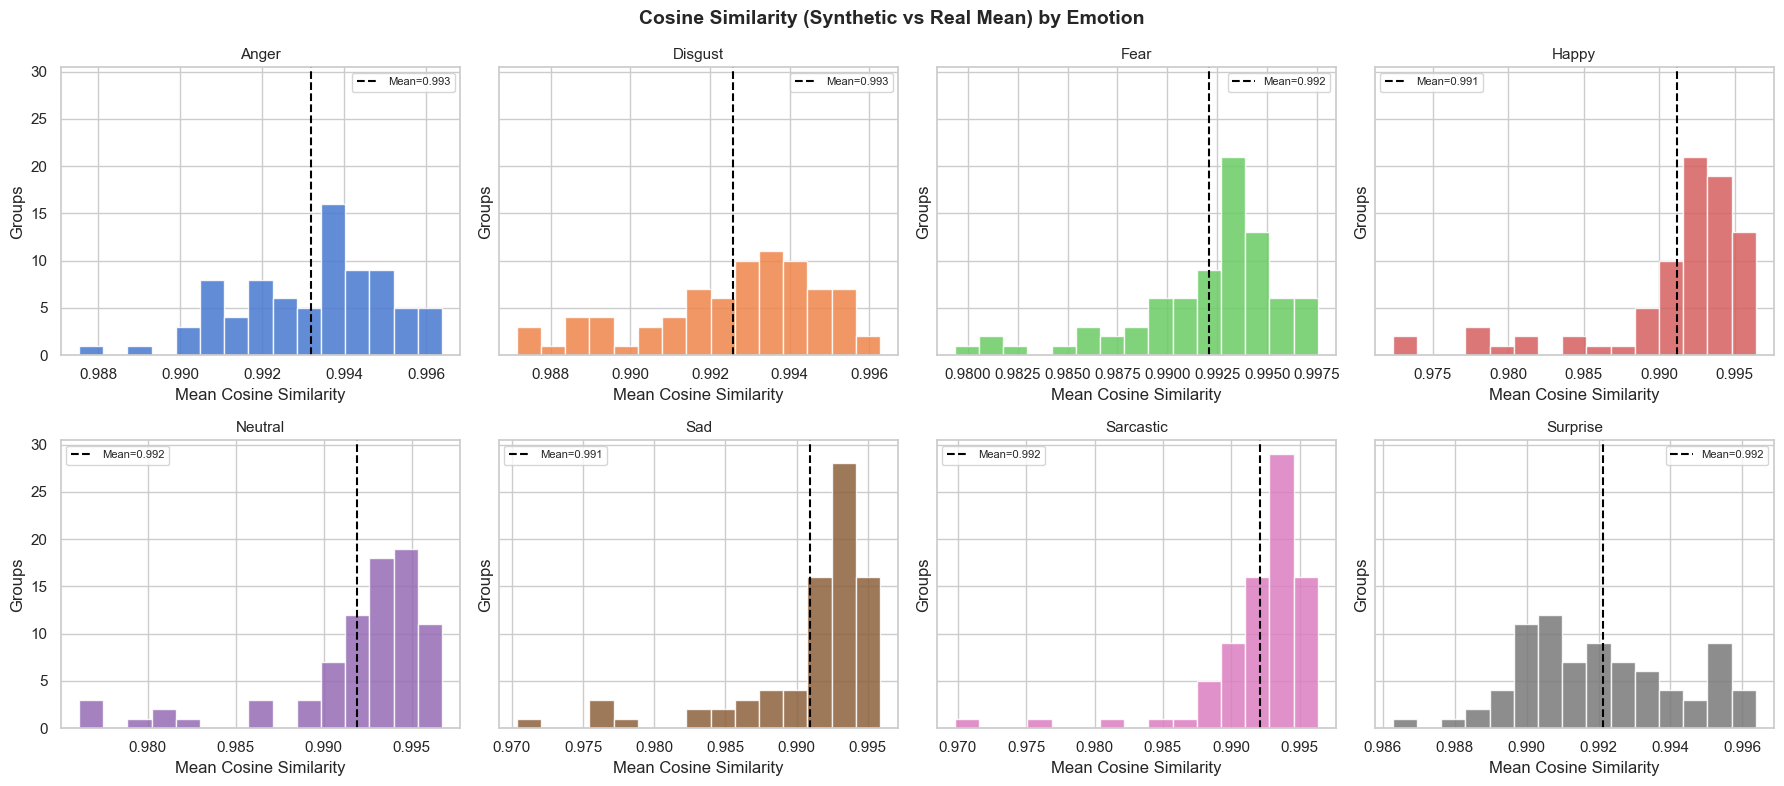


Cosine Similarity Summary by Emotion:
           Mean Cosine  Min Cosine  Max Cosine    Std
emotion                                              
anger           0.9932      0.9875      0.9964 0.0018
disgust         0.9926      0.9872      0.9963 0.0022
fear            0.9921      0.9794      0.9975 0.0037
happy           0.9912      0.9723      0.9964 0.0052
neutral         0.9919      0.9761      0.9967 0.0046
sad             0.9910      0.9704      0.9959 0.0050
sarcastic       0.9921      0.9698      0.9963 0.0040
surprise        0.9921      0.9863      0.9964 0.0022

  ✅ All groups have mean cosine similarity ≥ 0.7.


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
fig.suptitle('Cosine Similarity (Synthetic vs Real Mean) by Emotion',
             fontsize=14, fontweight='bold')

palette = sns.color_palette('muted', len(EMOTIONS))

for idx, emotion in enumerate(EMOTIONS):
    ax    = axes[idx // 4][idx % 4]
    data  = log_df[log_df['emotion'] == emotion]['mean_cosine']

    ax.hist(data, bins=15, color=palette[idx], alpha=0.85, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={data.mean():.3f}')
    ax.set_title(emotion.capitalize(), fontsize=11)
    ax.set_xlabel('Mean Cosine Similarity')
    ax.set_ylabel('Groups')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('./outputs/cosine_sim_by_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary = log_df.groupby('emotion')['mean_cosine'].agg(['mean','min','max','std'])
summary.columns = ['Mean Cosine', 'Min Cosine', 'Max Cosine', 'Std']
print('\nCosine Similarity Summary by Emotion:')
print(summary.to_string(float_format='{:.4f}'.format))

low_quality = log_df[log_df['mean_cosine'] < 0.7]
if len(low_quality) > 0:
    print(f'\n  ⚠️  {len(low_quality)} groups have mean cosine < 0.7 (low quality):')
    print(low_quality[['actor','sentence','emotion','mean_cosine']].to_string(index=False))
else:
    print('\n  ✅ All groups have mean cosine similarity ≥ 0.7.')

---
## 📊 CELL 9 — t-SNE: Real vs Synthetic Embeddings Across All Emotions

Running t-SNE on sampled embeddings...
✅ t-SNE complete.


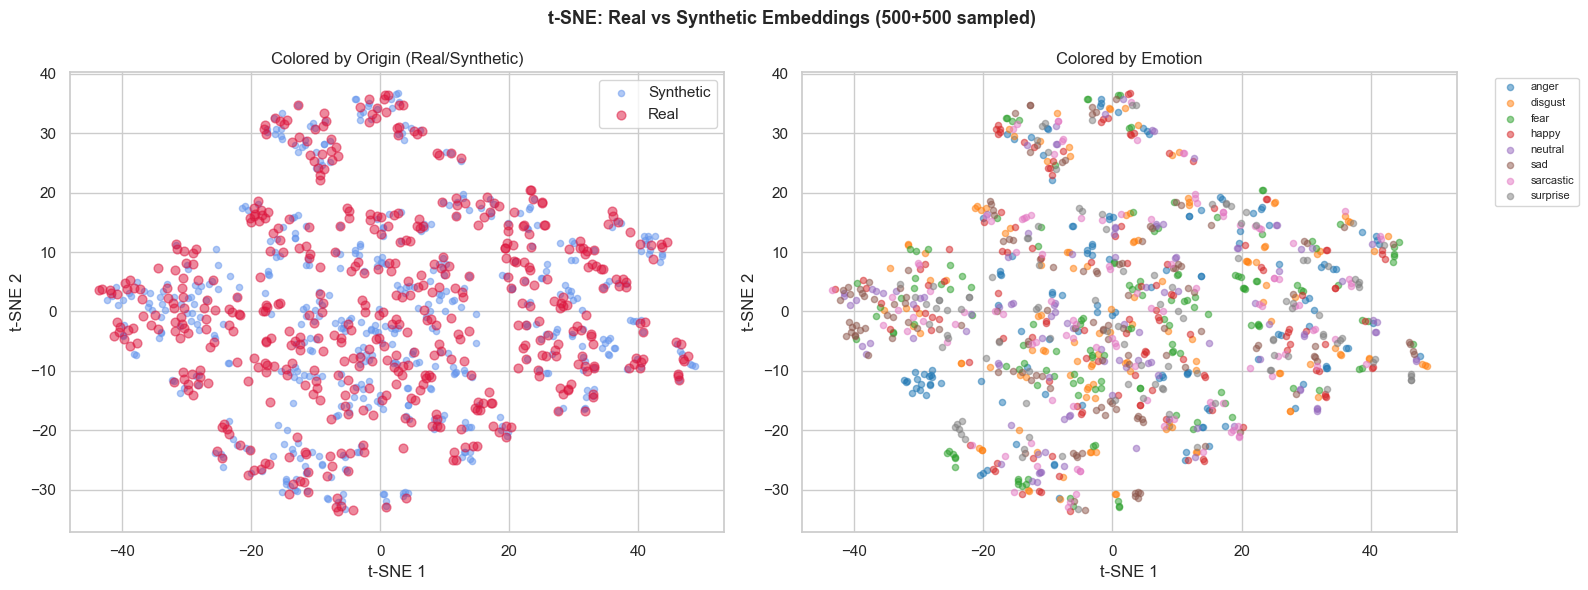


✅ Notebook 2 complete!
   Proceed to Notebook 3 (HiFi-GAN Decoding) if t-SNE shows good overlap.
   ✔ Ideal result: Real and Synthetic points overlap well by emotion cluster.


In [9]:
# Sample a subset for t-SNE (too slow on all 25,200 points)
N_SAMPLE_REAL  = 500
N_SAMPLE_SYNTH = 500

real_idx  = np.random.choice(len(emb_matrix), N_SAMPLE_REAL, replace=False)
synth_idx = np.random.choice(len(synth_matrix), N_SAMPLE_SYNTH, replace=False)

real_sub   = emb_matrix[real_idx]
synth_sub  = synth_matrix[synth_idx]
real_sub_labels  = label_df.iloc[real_idx].reset_index(drop=True)
synth_sub_labels = synth_labels.iloc[synth_idx].reset_index(drop=True)

combined_for_tsne  = np.vstack([real_sub, synth_sub])
origin_labels      = ['Real'] * N_SAMPLE_REAL + ['Synthetic'] * N_SAMPLE_SYNTH
emotion_labels_all = list(real_sub_labels['emotion']) + list(synth_sub_labels['emotion'])

print('Running t-SNE on sampled embeddings...')
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_for_tsne)
pca50 = PCA(n_components=50, random_state=42).fit_transform(combined_scaled)
tsne_coords = TSNE(n_components=2, perplexity=40, random_state=42,
                   learning_rate='auto', init='pca').fit_transform(pca50)
print('✅ t-SNE complete.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('t-SNE: Real vs Synthetic Embeddings (500+500 sampled)',
             fontsize=13, fontweight='bold')

# Real vs Synthetic
palette_rs = {'Real': 'crimson', 'Synthetic': 'cornflowerblue'}
for label in ['Synthetic', 'Real']:   # Plot synth first (behind)
    mask = np.array(origin_labels) == label
    axes[0].scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                    c=palette_rs[label], label=label, alpha=0.5,
                    s=20 if label == 'Synthetic' else 40,
                    zorder=2 if label == 'Synthetic' else 3)
axes[0].set_title('Colored by Origin (Real/Synthetic)')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].legend()

# By emotion
emo_palette = sns.color_palette('tab10', len(EMOTIONS))
emo_color_map = {e: emo_palette[i] for i, e in enumerate(EMOTIONS)}
for emotion in EMOTIONS:
    mask = np.array(emotion_labels_all) == emotion
    axes[1].scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                    c=[emo_color_map[emotion]], label=emotion, alpha=0.5, s=20)
axes[1].set_title('Colored by Emotion')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('./outputs/tsne_real_vs_synth.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Notebook 2 complete!')
print('   Proceed to Notebook 3 (HiFi-GAN Decoding) if t-SNE shows good overlap.')
print('   ✔ Ideal result: Real and Synthetic points overlap well by emotion cluster.')